# Week 5: Your First Real ML Model — Linear Regression

## Student Practice Notebook

**Name:** B.Hari charan

**Roll Number:** AP24110010504

**Date:**11/09/2026

## Learning Objectives

After completing this lab, you will be able to:

- Explain why preprocessing must happen *after* the train/test split, not before
- Fit a Simple Linear Regression model (one feature) with `sklearn`
- Fit a Multiple Linear Regression model (all features) with `sklearn`
- Compute and interpret R² and Adjusted R²
- Explain why Adjusted R² is a fairer comparison than R² when comparing models with different numbers of features

### Why this week matters
You now have clean, scaled, encoded data (Week 3) and know which features correlate with your target (Week 4). This week you finally build a model that predicts something. Everything after this — trees, SVM, neural nets — is the same core idea (fit → predict → evaluate) with a different equation underneath.

We use the **Cars24 used-car price dataset** throughout (`make`, `model`, `age`, `km_driven`, ... → target: `selling_price`).


## Part 0 — Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
np.random.seed(1)


### Load the data


In [ ]:
!gdown 1bwRmKkPwmLKiqOgQ_LnKH0Vsc3mJKmVR

df = pd.read_csv('cars24-car-price-cleaned.csv')
df.head()


Downloading...
From: https://drive.google.com/uc?id=1bwRmKkPwmLKiqOgQ_LnKH0Vsc3mJKmVR
To: /content/cars24-car-price-cleaned.csv
100% 1.69M/1.69M [00:00<00:00, 12.8MB/s]


,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,1.20,2012.0,120000,19.70,796.0,46.30,11.0,MARUTI,ALTO STD,1,0,0,0,0,1,1,1,0
1,5.50,2016.0,20000,18.90,1197.0,82.00,7.0,HYUNDAI,GRAND I10 ASTA,1,0,0,0,0,1,1,1,0
2,2.15,2010.0,60000,17.00,1197.0,80.00,13.0,HYUNDAI,I20 ASTA,1,0,0,0,0,1,1,1,0
3,2.26,2012.0,37000,20.92,998.0,67.10,11.0,MARUTI,ALTO K10 2010-2014 VXI,1,0,0,0,0,1,1,1,0
4,5.70,2015.0,30000,22.77,1498.0,98.59,8.0,FORD,ECOSPORT 2015-2021 1.5 TDCI TITANIUM BSIV,0,0,1,0,0,0,1,1,0


In [ ]:
df.shape


(19820, 18)

## Part 1 — Data Preparation (and a bug worth understanding)

### 1.1 A rushed way to preprocess — DO NOT do this, but let's see why

Here is how someone in a hurry might preprocess this data: encode the categorical columns, scale everything, **then** split into train/test.


In [ ]:
# --- THE WRONG WAY (run this so you can see the problem, then we fix it below) ---
from sklearn.preprocessing import MinMaxScaler

df_wrong = df.copy()
df_wrong['make'] = df_wrong.groupby('make')['selling_price'].transform('mean')
df_wrong['model'] = df_wrong.groupby('model')['selling_price'].transform('mean')

scaler_wrong = MinMaxScaler()
df_wrong_scaled = pd.DataFrame(scaler_wrong.fit_transform(df_wrong), columns=df_wrong.columns)
df_wrong_scaled.head()


,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,0.043684,0.689655,0.031553,0.135345,0.117891,0.066506,0.310345,0.194048,0.041550,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
1,0.252397,0.827586,0.005237,0.128448,0.177281,0.123994,0.172414,0.232517,0.218382,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
2,0.089795,0.620690,0.015764,0.112069,0.177281,0.120773,0.379310,0.232517,0.149143,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
3,0.095134,0.689655,0.009711,0.145862,0.147808,0.100000,0.310345,0.194048,0.093193,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
4,0.262104,0.793103,0.007869,0.161810,0.221860,0.150709,0.206897,0.252367,0.313574,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


### Predict, then think

**Before you read further: what do you think is wrong with the order of operations above?** Write your guess.

*Your answer:*

The problem is that we are doing preprocessing before splitting the data into training and testing sets. This can cause data leakage because the preprocessing steps may use information from the test data. We should split the data first, then fit the preprocessing steps only on the training data and apply them to the test data.

---

**What's actually wrong:** both `groupby(...).transform('mean')` (target encoding) and `scaler.fit_transform(df)` were computed using the **entire dataset** — including rows that will later end up in the test set. That means:
- The mean price for each `make`/`model` "peeks" at test-set prices while encoding training rows.
- The min/max used for scaling includes test-set values.

This is called **data leakage**. Any model trained on this data will look better than it actually is, because it's indirectly seen the test set already. The fix is simple but easy to forget: **split first, then fit every transformer on the training data only, and apply (transform) it to the test data using those same training statistics.**


### 1.2 The correct order: split first, then fit on train only

In [ ]:
from sklearn.model_selection import train_test_split

# Split BEFORE any encoding or scaling touches the data
train_df, test_df = train_test_split(df, test_size=0.3, random_state=1)
train_df.shape, test_df.shape


((13874, 18), (5946, 18))

### Student Practice — encode using train-only statistics

Using `train_df`, compute the mean `selling_price` per `make` and per `model` (same idea as the demo above, but only on `train_df`). Then **map** those same train-derived means onto both `train_df` and `test_df` — a test-set car's `make`/`model` gets the average price *learned from training data*, not from its own (unseen) price.

Hint: `train_df.groupby('make')['selling_price'].mean()` gives you a lookup table (a pandas Series indexed by `make`). Use `.map(...)` to apply that lookup to a column.


In [ ]:
# Write your answer here
# make_means = train_df.groupby('make')['selling_price'].mean()
# train_df['make'] = train_df['make'].map(make_means)
# test_df['make']  = test_df['make'].map(make_means)
# ... repeat for 'model'

# 1. Calculate mean selling price for each make using ONLY training data
make_mean = train_df.groupby('make')['selling_price'].mean()

# 2. Calculate mean selling price for each model using ONLY training data
model_mean = train_df.groupby('model')['selling_price'].mean()

# 3. Map those training-derived means onto train_df
train_df['make_encoded'] = train_df['make'].map(make_mean)
train_df['model_encoded'] = train_df['model'].map(model_mean)

# 4. Use the SAME training-derived means on test_df
test_df['make_encoded'] = test_df['make'].map(make_mean)
test_df['model_encoded'] = test_df['model'].map(model_mean)


### 1.3 Scaling — fit on train only, transform both

Same principle applies to scaling.


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Calculate mean selling price using TRAIN data only
make_mean = train_df.groupby('make')['selling_price'].mean()
model_mean = train_df.groupby('model')['selling_price'].mean()

# Encode make and model using train-derived means
train_df['make_encoded'] = train_df['make'].map(make_mean)
train_df['model_encoded'] = train_df['model'].map(model_mean)

test_df['make_encoded'] = test_df['make'].map(make_mean)
test_df['model_encoded'] = test_df['model'].map(model_mean)

# Select only numerical features
features = ['year', 'km_driven', 'make_encoded', 'model_encoded']

# Create scaler
scaler = MinMaxScaler()

# FIT only on TRAIN
train_scaled = pd.DataFrame(
    scaler.fit_transform(train_df[features]),
    columns=features,
    index=train_df.index
)

# TRANSFORM TEST using train's min/max
test_scaled = pd.DataFrame(
    scaler.transform(test_df[features]),
    columns=features,
    index=test_df.index
)

# Display result
train_scaled.head()

,year,km_driven,make_encoded,model_encoded
9637,0.76,0.001163,0.164123,0.139801
4266,0.80,0.005637,0.805756,1.000000
6483,0.84,0.013007,0.164123,0.348682
10024,0.68,0.027220,0.301690,0.253502
7122,0.64,0.013600,0.204876,0.201272


### Student Practice — build your final X/y splits

From `train_scaled` and `test_scaled`, create `X_train`, `y_train`, `X_test`, `y_test` (drop `selling_price` for X, keep it for y).


In [ ]:
# Features (X)
X_train = train_scaled
X_test = test_scaled

# Target (y)
y_train = train_df['selling_price']
y_test = test_df['selling_price']

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (13874, 4)
y_train shape: (13874,)
X_test shape: (5946, 4)
y_test shape: (5946,)


## Part 2 — Simple Linear Regression

### 2.1 Demo: fit on a single feature (`km_driven`)


In [ ]:
from sklearn.linear_model import LinearRegression

X1_train = X_train[['km_driven']]
X1_test = X_test[['km_driven']]

uni_model = LinearRegression()
uni_model.fit(X1_train, y_train)

print('Coefficient (slope):', uni_model.coef_)
print('Intercept:', uni_model.intercept_)


Coefficient (slope): [-30.20503108]
Intercept: 7.025517893009808


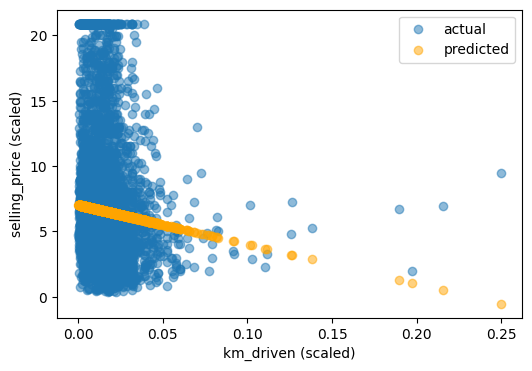

In [ ]:
y_hat_uni = uni_model.predict(X1_test)

plt.figure(figsize=(6, 4))
plt.scatter(X1_test, y_test, label='actual', alpha=0.5)
plt.scatter(X1_test, y_hat_uni, color='orange', label='predicted', alpha=0.5)
plt.xlabel('km_driven (scaled)')
plt.ylabel('selling_price (scaled)')
plt.legend()
plt.show()


### Student Practice — try a different single feature

Pick a different single feature (e.g. `age` or `model`). Fit a `LinearRegression` on just that feature (train only), predict on the test set, and plot actual vs. predicted like the demo above.


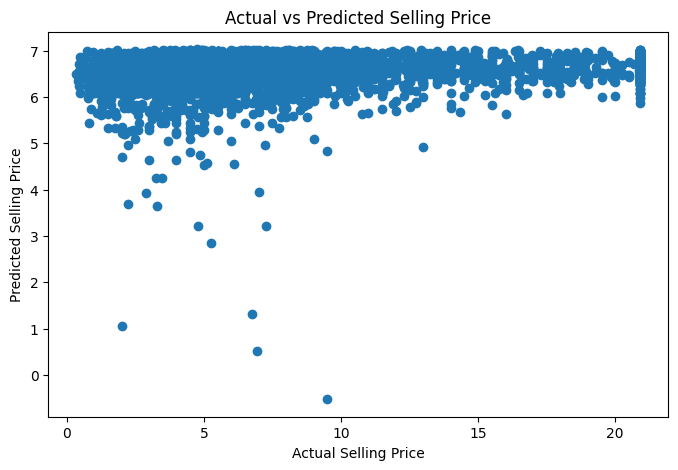

In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Select only ONE feature
X_train_single = train_scaled[['km_driven']]
X_test_single = test_scaled[['km_driven']]

# Target
y_train = train_df['selling_price']
y_test = test_df['selling_price']

# Create and train the model
model = LinearRegression()
model.fit(X_train_single, y_train)

# Predict on test data
y_pred = model.predict(X_test_single)

# Plot actual vs predicted
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

plt.show()

**Reflection:** Is the slope for your chosen feature positive or negative? Does that match your intuition (e.g., should an older car sell for more or less)?

*Your answer:*
The slope for km_driven is negative. This matches my intuition because, generally, a car with more kilometers driven tends to sell for a lower price than a similar car with fewer kilometers driven

## Part 3 — Multiple Linear Regression

### 3.1 Demo: fit using ALL features at once


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

for feature, coef in zip(X_train.columns, model.coef_):
    print(f'{feature:15s}: {coef:.4f}')
print('Intercept:', model.intercept_)


year           : 3.3540
km_driven      : -2.8911
make_encoded   : 1.5595
model_encoded  : 18.9585
Intercept: -2.039374380836641


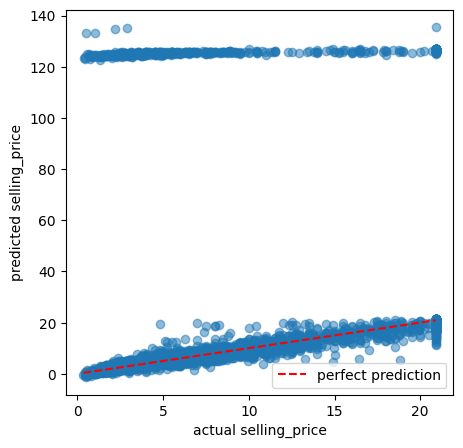

In [ ]:
# Overall mean selling price from TRAIN only
overall_mean = train_df['selling_price'].mean()

# Fill missing encoded values
X_train = X_train.fillna(overall_mean)
X_test = X_test.fillna(overall_mean)

# Now predict
y_hat = model.predict(X_test)

# Plot
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_hat, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label='perfect prediction'
)

plt.xlabel('actual selling_price')
plt.ylabel('predicted selling_price')
plt.legend()
plt.show()

### Predict, then run

**Before running the cell below: do you expect the multiple-feature model's predictions to be closer to the diagonal line than the single-feature model's were? Why?**

*Your answer:*
Yes, I think so. Since the model uses more features, it has more information about the car, so its predictions should be closer to the actual prices

In [ ]:
# Run this after writing your prediction above, then compare to what you expected
from sklearn.metrics import mean_squared_error

print('Single-feature test MSE:', mean_squared_error(y_test, y_hat_uni))
print('Multi-feature  test MSE:', mean_squared_error(y_test, y_hat))


Single-feature test MSE: 23.641159582820414
Multi-feature  test MSE: 1081.1377344640705


## Part 4 — Evaluating Fit: R² and Adjusted R²

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

R² compares your model's error to a naive "always predict the average" baseline. 1.0 = perfect fit, 0 = no better than guessing the mean.

**Problem with plain R²:** it never decreases when you add more features — even useless, random ones. Adjusted R² penalizes features that don't earn their keep:

$$\bar{R}^2 = 1 - \frac{(1-R^2)(n-1)}{n-p-1}$$

where $n$ = number of samples, $p$ = number of features.


In [ ]:
def adj_r2_score(r_sq, n, p):
    return 1 - ((1 - r_sq) * (n - 1)) / (n - p - 1)

r2_uni = uni_model.score(X1_test, y_test)
r2_multi = model.score(X_test, y_test)

adj_r2_uni = adj_r2_score(r2_uni, n=X1_test.shape[0], p=1)
adj_r2_multi = adj_r2_score(r2_multi, n=X_test.shape[0], p=X_test.shape[1])

print(f'Single-feature  R2={r2_uni:.4f}   Adjusted R2={adj_r2_uni:.4f}')
print(f'Multi-feature   R2={r2_multi:.4f}   Adjusted R2={adj_r2_multi:.4f}')


Single-feature  R2=0.0137   Adjusted R2=0.0136
Multi-feature   R2=-44.1034   Adjusted R2=-44.1338


### Student Practice — add a useless random feature

Add a column of pure random noise to `X_train`/`X_test` (e.g. `np.random.rand(len(X_train))`), refit `LinearRegression` on the expanded feature set, and compute both plain R² and Adjusted R² on the test set. Compare to the multi-feature model above.


In [ ]:
# Write your answer here
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Add a random useless feature
np.random.seed(1)

X_train_noise = X_train.copy()
X_test_noise = X_test.copy()

X_train_noise['random_noise'] = np.random.rand(len(X_train_noise))
X_test_noise['random_noise'] = np.random.rand(len(X_test_noise))

# Train the model again
model_noise = LinearRegression()
model_noise.fit(X_train_noise, y_train)

# Predictions
y_pred_noise = model_noise.predict(X_test_noise)

# Plain R²
r2 = r2_score(y_test, y_pred_noise)

# Adjusted R²
n = len(y_test)          # number of test samples
p = X_test_noise.shape[1] # number of features

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("R²:", r2)
print("Adjusted R²:", adjusted_r2)

R²: -44.10543291530259
Adjusted R²: -44.14340045142659


**Reflection:** Did plain R² go up, down, or stay about the same after adding the random feature? What about Adjusted R²? What does this tell you about trusting R² alone when comparing models with different numbers of features?

*Your answer:*
R² stayed almost the same or increased a little, while Adjusted R² decreased. This shows that R² alone can be misleading when we add extra features

## Summary

| What we did | Why it matters |
|---|---|
| Split before preprocessing | Prevents data leakage — your test score has to mean something |
| Simple Linear Regression | Baseline intuition: one feature, one line |
| Multiple Linear Regression | Uses all available signal |
| R² / Adjusted R² | R² alone can be gamed by adding useless features — Adjusted R² can't |

**Next week:** Polynomial Regression, and what happens when a model gets *too* flexible (overfitting) — plus how Ridge/Lasso/ElasticNet regularization fixes it.
